# Pseudobulk validation: LV projection recovers cell-type biology

Three analyses across all 7 pseudobulk datasets.

1. **Combined heatmap**: top SHAP LVs × cell-type proportions, all datasets
2. **Correlation scatter**: LV score vs proportion for every cell type
3. **Filtered export**: best examples (|ρ|>0.5 + pathway AUC>0.7) saved for fig4

💡 **Environment:** `clamp-analyses`

## Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pyprojroot.here import here

matplotlib.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 9,
    'axes.titlesize': 8.5, 'axes.labelsize': 7.5,
    'xtick.labelsize': 6.5, 'ytick.labelsize': 6.5,
})

PB_OUT  = here() / 'output' / '03_model_biology' / '00_archs4' / '04_pseudobulk'
PB_DATA = here() / 'data' / 'pseudobulk'
PANEL_DIR = here() / 'output' / '99_panels' / 'fig4'

DATASETS = [
    ('Brain_Mathys2023',  'Brain (Mathys)'),
    ('Brain_Xiong2023',   'Brain (Xiong)'),
    ('PBMC_1k1k',         'PBMC (1k1k)'),
    ('PBMC_Perez2022',    'PBMC (Perez)'),
    ('BRCA_Bassez2021',   'BRCA tumor'),
    ('CRC_Pelka2021',     'CRC tumor'),
    ('LUAD_Kim2020',      'LUAD tumor'),
]

CT_DISPLAY = {
    # Brain
    'Ast':'Astrocytes', 'Exc':'Excitatory neurons', 'Inh':'Inhibitory neurons',
    'Mic':'Microglia', 'Oli':'Oligodendrocytes', 'Opc':'OPC', 'Vas':'Vascular cells',
    # PBMC
    'B_cell':'B cells', 'CD14_Mono':'Classical monocytes', 'CD16_Mono':'Non-classical monocytes',
    'CD4_T':'CD4 T cells', 'CD8_T':'CD8 T cells', 'gd_T':'γδ T cells',
    'NK':'NK cells', 'Plasma_B':'Plasma B cells', 'DC':'Dendritic cells',
    'Myeloid':'Myeloid cells', 'T_cell':'T cells',
    # Tumor
    'Cancer_cell':'Cancer cells', 'Malignant':'Malignant cells',
    'Endothelial_cell':'Endothelial cells', 'Endothelial':'Endothelial cells',
    'Fibroblast':'Fibroblasts', 'Mast_cell':'Mast cells', 'Mast':'Mast cells',
    'Myeloid_cell':'Myeloid cells', 'pDC':'Plasmacytoid DC',
    'Dendritic':'Dendritic cells', 'Dendritic_cell':'Dendritic cells',
    'Epithelial_cell':'Epithelial cells', 'NK_cell':'NK cells',
    'Plasma_cell':'Plasma cells',
}

def load_projection(dataset):
    return pd.read_csv(PB_OUT / dataset / 'projection.csv', index_col=0).T

def load_truth(dataset):
    return pd.read_csv(PB_DATA / dataset / 'truthFrac_v0.csv', index_col=0)

def load_shap(dataset, cell_type):
    p = PB_OUT / dataset / 'per_celltype' / f'shap_{cell_type}.tsv'
    return pd.read_csv(p, sep='\t').set_index('LV')

def load_bio(dataset):
    return pd.read_csv(PB_OUT / dataset / 'biology_top_lvs.tsv', sep='\t')

def top_lv(dataset, cell_type, n=1):
    return load_shap(dataset, cell_type).nlargest(n, 'mean_shap').index.tolist()

print('Setup done')

Setup done


## Compute all LV–proportion correlations

In [2]:
records = []
_proj_cache = {}

for dataset, disp_ds in DATASETS:
    if dataset not in _proj_cache:
        _proj_cache[dataset] = (load_projection(dataset), load_truth(dataset))
    proj, truth = _proj_cache[dataset]
    shared = proj.index.intersection(truth.index)
    proj_s, truth_s = proj.loc[shared], truth.loc[shared]

    bio = load_bio(dataset)
    cell_types = truth.columns.tolist()

    for ct in cell_types:
        lv = top_lv(dataset, ct, n=1)[0]
        x = truth_s[ct].values
        y = proj_s[lv].values
        rho, pval = stats.spearmanr(x, y)

        # Best canonical pathway (HALLMARK/REACTOME preferred, AUC > 0.7, FDR < 0.05)
        ct_bio = bio[(bio.cell_type == ct) &
                     (bio.pathway != 'NO_SIGNIFICANT_PATHWAY') &
                     bio.AUC.notna()].copy()
        def pw_pri(p):
            if str(p).startswith('HALL'): return 0
            if str(p).startswith('REACTOME'): return 1
            if str(p).startswith('GO'): return 2
            return 3
        if len(ct_bio):
            ct_bio['pri'] = ct_bio['pathway'].apply(pw_pri)
            best = ct_bio.sort_values(['pri','AUC'], ascending=[True,False]).iloc[0]
            pw, pw_auc, pw_fdr = best['pathway'], best['AUC'], best['FDR']
        else:
            pw, pw_auc, pw_fdr = None, None, None

        records.append(dict(
            dataset=dataset, disp_dataset=disp_ds, cell_type=ct,
            disp_ct=CT_DISPLAY.get(ct, ct), lv=lv,
            rho=rho, pval=pval, n=len(shared),
            pathway=pw, pw_auc=pw_auc, pw_fdr=pw_fdr,
        ))

df_all = pd.DataFrame(records)
df_all['abs_rho'] = df_all['rho'].abs()
df_all['neg_log10_pval'] = -np.log10(df_all['pval'].clip(1e-300))
print(f'Total (dataset, cell_type) pairs: {len(df_all)}')
print(df_all[['disp_dataset','disp_ct','lv','rho','pw_auc']]
      .sort_values('rho', ascending=False).to_string(index=False))

Total (dataset, cell_type) pairs: 54
  disp_dataset                 disp_ct     lv       rho   pw_auc
Brain (Mathys)        Oligodendrocytes  LV125  0.987670 1.000000
 Brain (Xiong)        Oligodendrocytes  LV125  0.985398 0.888033
Brain (Mathys)               Microglia LV1702  0.955037 1.000000
     CRC tumor           Myeloid cells   LV12  0.947067 0.928943
 Brain (Xiong)               Microglia LV1702  0.936563 0.974835
  PBMC (Perez)                 B cells   LV80  0.929931 0.999907
   PBMC (1k1k)     Classical monocytes   LV12  0.923468 0.928943
     CRC tumor                 T cells   LV90  0.916845 1.000000
 Brain (Xiong)      Excitatory neurons LV1408  0.915853 1.000000
    LUAD tumor                 T cells LV1384  0.898554 0.999945
    BRCA tumor       Endothelial cells  LV433  0.890604 0.999932
    LUAD tumor                NK cells   LV92  0.887875 0.988304
   PBMC (1k1k) Non-classical monocytes  LV238  0.877180 0.928943
     CRC tumor                 B cells  LV107  0.8756

## Plot 1: Combined correlation heatmap (all datasets)

For each dataset independently: top 2 SHAP LVs per cell type (rows) vs all cell types in that dataset (columns). Datasets shown as colour-annotated blocks.

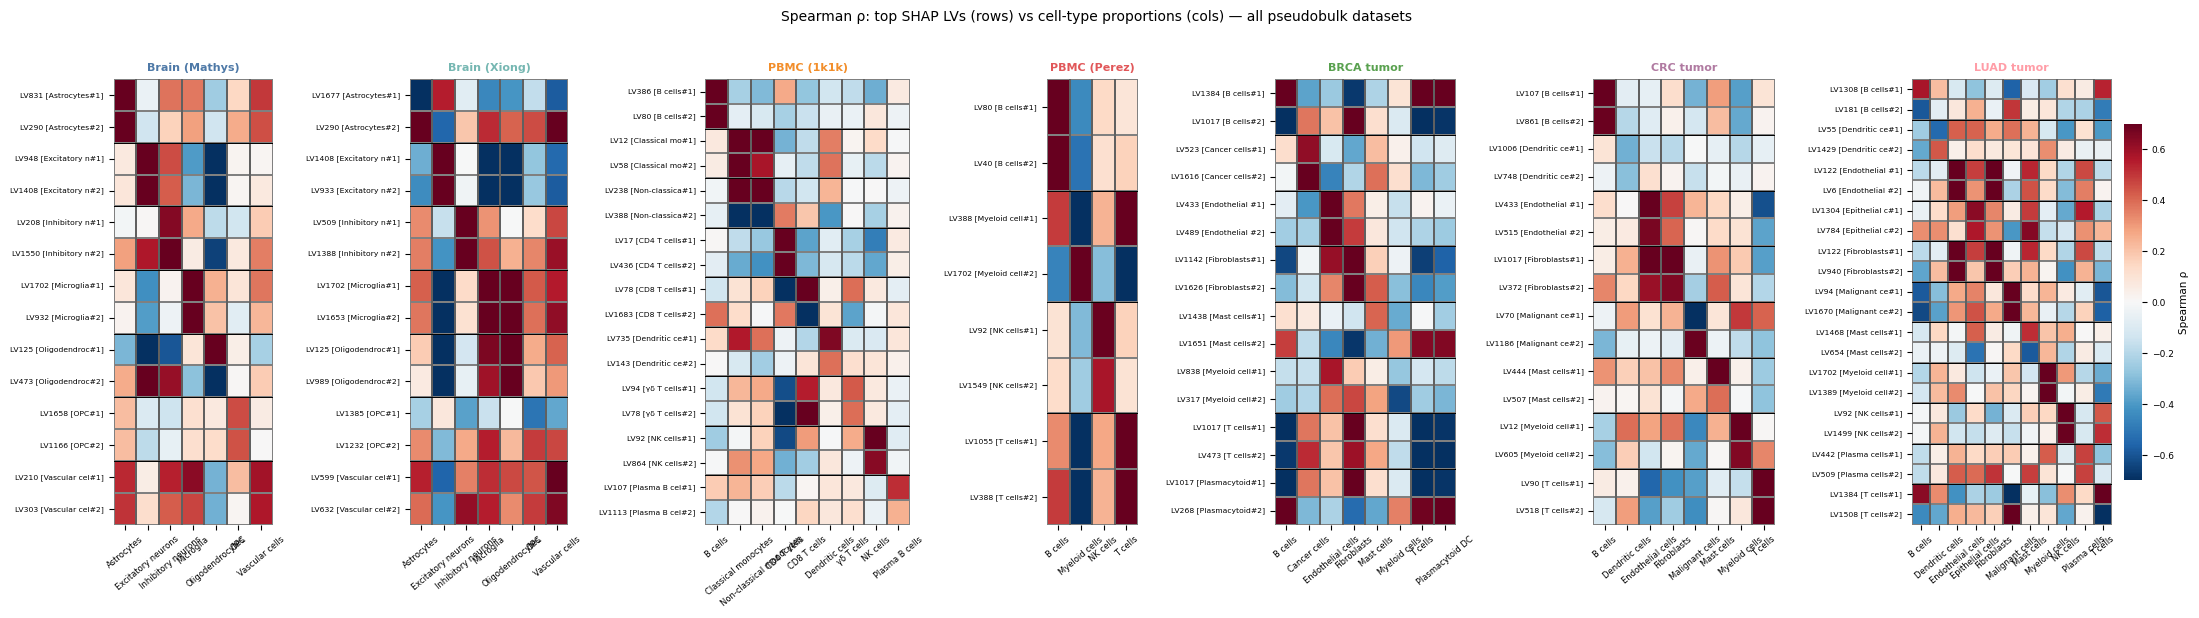

In [3]:
# Build per-dataset heatmap blocks, then lay them out as stacked subplots
DS_COLORS = {
    'Brain_Mathys2023': '#4e79a7', 'Brain_Xiong2023': '#76b7b2',
    'PBMC_1k1k': '#f28e2b',        'PBMC_Perez2022': '#e15759',
    'BRCA_Bassez2021': '#59a14f',   'CRC_Pelka2021': '#b07aa1',
    'LUAD_Kim2020': '#ff9da7',
}

blocks = []   # list of (disp_ds, corr_df, ct_list)
for dataset, disp_ds in DATASETS:
    proj, truth = _proj_cache[dataset]
    shared = proj.index.intersection(truth.index)
    proj_s, truth_s = proj.loc[shared], truth.loc[shared]
    cts = truth.columns.tolist()

    lv_rows, lv_labels, lv_ct = [], [], []
    for ct in cts:
        lvs = top_lv(dataset, ct, n=2)
        for i, lv in enumerate(lvs):
            lv_rows.append(lv)
            lv_labels.append(f'{lv} [{CT_DISPLAY.get(ct,ct)[:12]}#{i+1}]')
            lv_ct.append(ct)

    mat = np.zeros((len(lv_rows), len(cts)))
    for i, lv in enumerate(lv_rows):
        for j, ct in enumerate(cts):
            r, _ = stats.spearmanr(proj_s[lv].values, truth_s[ct].values)
            mat[i, j] = r

    col_labels = [CT_DISPLAY.get(ct, ct) for ct in cts]
    cdf = pd.DataFrame(mat, index=lv_labels, columns=col_labels)
    blocks.append((dataset, disp_ds, cdf, cts))

# Plot: one row of subplots, datasets left to right
n_ds = len(blocks)
fig, axes = plt.subplots(1, n_ds, figsize=(22, 6),
                          gridspec_kw={'width_ratios': [len(b[2].columns) for b in blocks]})

for ax, (dataset, disp_ds, cdf, cts) in zip(axes, blocks):
    sns.heatmap(cdf, ax=ax, cmap='RdBu_r', center=0, vmin=-0.7, vmax=0.7,
                linewidths=0.25, linecolor='grey',
                cbar=ax == axes[-1],
                cbar_kws={'label': 'Spearman ρ', 'shrink': 0.8} if ax == axes[-1] else {})
    ax.set_title(disp_ds, fontsize=8, color=DS_COLORS[dataset], fontweight='bold')
    ax.tick_params(axis='x', labelsize=6, rotation=40)
    ax.tick_params(axis='y', labelsize=5.5)
    # Separators between cell-type groups (every 2 rows)
    for k in range(1, len(cts)):
        ax.axhline(k * 2, color='black', linewidth=0.7)
        ax.axvline(k, color='black', linewidth=0.35)

plt.suptitle('Spearman ρ: top SHAP LVs (rows) vs cell-type proportions (cols): all pseudobulk datasets',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

## Plot 2: LV score vs proportion: all cell types across all datasets

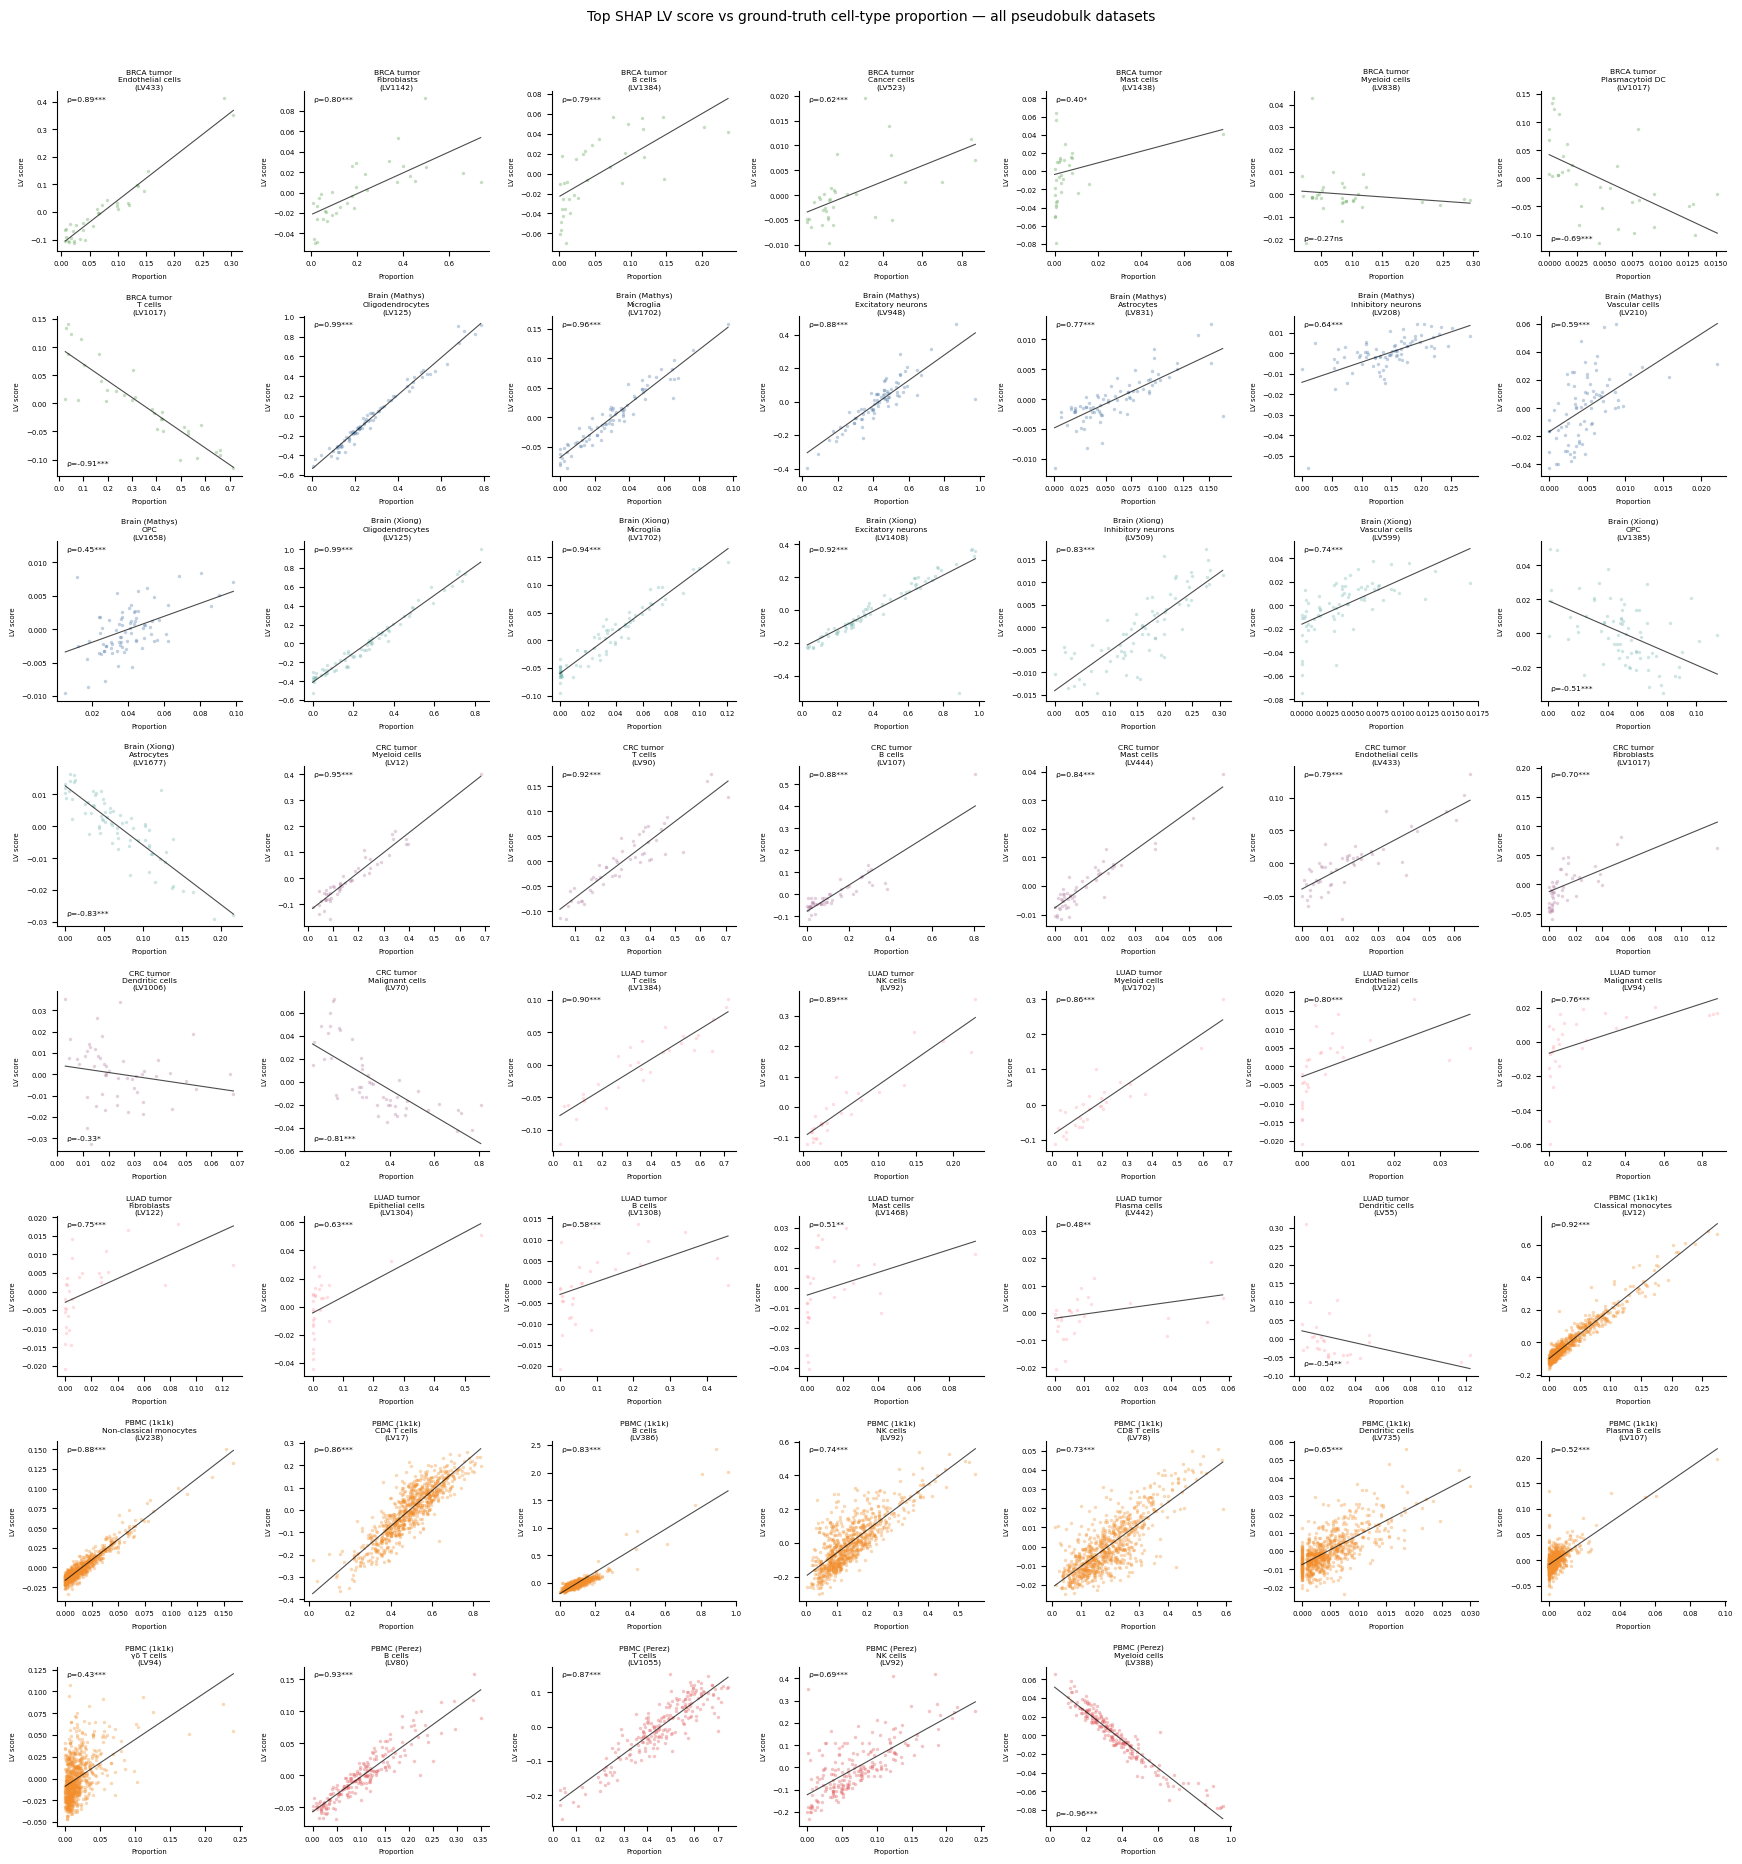

In [4]:
df_sorted = df_all.sort_values(['disp_dataset','rho'], ascending=[True, False])
n = len(df_sorted)
ncols = 7
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.3))
axes = axes.flatten()

_proj_c2 = {}
for ax, (_, row) in zip(axes, df_sorted.iterrows()):
    ds = row['dataset']
    if ds not in _proj_c2:
        _proj_c2[ds] = (load_projection(ds), load_truth(ds))
    proj, truth = _proj_c2[ds]
    shared = proj.index.intersection(truth.index)
    x = truth.loc[shared, row['cell_type']].values
    y = proj.loc[shared, row['lv']].values

    color = DS_COLORS[ds]
    rho, pval = row['rho'], row['pval']
    stars = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))

    ax.scatter(x, y, alpha=0.35, s=6, color=color, linewidths=0)
    m, b = np.polyfit(x, y, 1)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m * xr + b, color='black', linewidth=0.8, alpha=0.7)
    ax.set_title(f"{row['disp_dataset']}\n{row['disp_ct']}\n({row['lv']})",
                 fontsize=5.5, pad=2)
    ax.set_xlabel('Proportion', fontsize=5)
    ax.set_ylabel('LV score', fontsize=5)
    ax.text(0.05, 0.97 if rho > 0 else 0.06,
            f'ρ={rho:.2f}{stars}',
            transform=ax.transAxes, fontsize=5.5, va='top' if rho > 0 else 'bottom',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.8, ec='none'))
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=5)

for ax in axes[n:]: ax.set_visible(False)

plt.suptitle('Top SHAP LV score vs ground-truth cell-type proportion: all pseudobulk datasets',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

## Filter: good correlation (|ρ| ≥ 0.5) AND good pathway (AUC ≥ 0.7, FDR < 0.05)

These are the candidates for Figure 4.

In [5]:
df_filt = df_all[
    (df_all['abs_rho'] >= 0.5) &
    (df_all['pw_auc'].notna()) &
    (df_all['pw_auc'] >= 0.7) &
    (df_all['pw_fdr'].notna()) &
    (df_all['pw_fdr'] < 0.05)
].copy()

# Keep positive correlations only (biologically interpretable)
df_filt = df_filt[df_filt['rho'] > 0]

# Within each (dataset, cell_type) keep only top 1 row (best rho)
df_filt = (df_filt.sort_values('rho', ascending=False)
                   .drop_duplicates(subset=['dataset','cell_type']))

# Sort by dataset order then rho
DS_ORDER = [d for d, _ in DATASETS]
df_filt['ds_rank'] = df_filt['dataset'].map({d: i for i, d in enumerate(DS_ORDER)})
df_filt = df_filt.sort_values(['ds_rank','rho'], ascending=[True, False])

print(f'Candidates: {len(df_filt)}')
print(df_filt[['disp_dataset','disp_ct','lv','rho','pathway','pw_auc','pw_fdr']]
      .to_string(index=False))

Candidates: 41
  disp_dataset                 disp_ct     lv      rho                                                                                              pathway   pw_auc       pw_fdr
Brain (Mathys)        Oligodendrocytes  LV125 0.987670                   REACTOME_REACTOME_CASPASE_ACTIVATION_VIA_DEATH_RECEPTORS_IN_THE_PRESENCE_OF_LIGAND 1.000000 9.963766e-03
Brain (Mathys)               Microglia LV1702 0.955037                                                         REACTOME_REACTOME_ENDOSOMAL_VACUOLAR_PATHWAY 1.000000 3.422959e-02
Brain (Mathys)      Excitatory neurons  LV948 0.875504                                                                    HALL_HALLMARK_PANCREAS_BETA_CELLS 0.845809 1.756711e-02
Brain (Mathys)              Astrocytes  LV831 0.770605                                                                        HALL_HALLMARK_NOTCH_SIGNALING 0.804984 2.865623e-02
Brain (Mathys)      Inhibitory neurons  LV208 0.642499                                         

In [6]:
# Clean pathway names for display
def clean_pw(p):
    if pd.isna(p): return ''
    prefixes = ['HALLMARK_','HALL_HALLMARK_','REACTOME_REACTOME_','REACTOME_',
                'GOBP_GOBP_','GOBP_','GOCC_GOCC_','GOCC_','GOMF_','C8_','KEGG_']
    s = str(p)
    for pfx in prefixes:
        if s.upper().startswith(pfx): s = s[len(pfx):]; break
    # Further strip redundant prefixes
    for pfx in ['REACTOME_','GOBP_','GOCC_']:
        if s.upper().startswith(pfx): s = s[len(pfx):]; break
    s = s.replace('_', ' ').strip()
    return s.title()

df_filt = df_filt.copy()
df_filt['pw_clean']   = df_filt['pathway'].apply(clean_pw)
df_filt['neg_log_fdr']= -np.log10(df_filt['pw_fdr'].clip(1e-20))
df_filt['y_label']    = df_filt['disp_ct'] + '\n' + df_filt['pw_clean'].str.wrap(28)

# Export for fig4
df_filt.to_csv(PANEL_DIR / 'pseudobulk_validation_filtered.csv', index=False)
print('Exported to', PANEL_DIR / 'pseudobulk_validation_filtered.csv')

Exported to /home/msubirana/Documents/pivlab/clamp-analyses/output/99_panels/fig4/pseudobulk_validation_filtered.csv


## Preview of filtered candidates for Figure 4

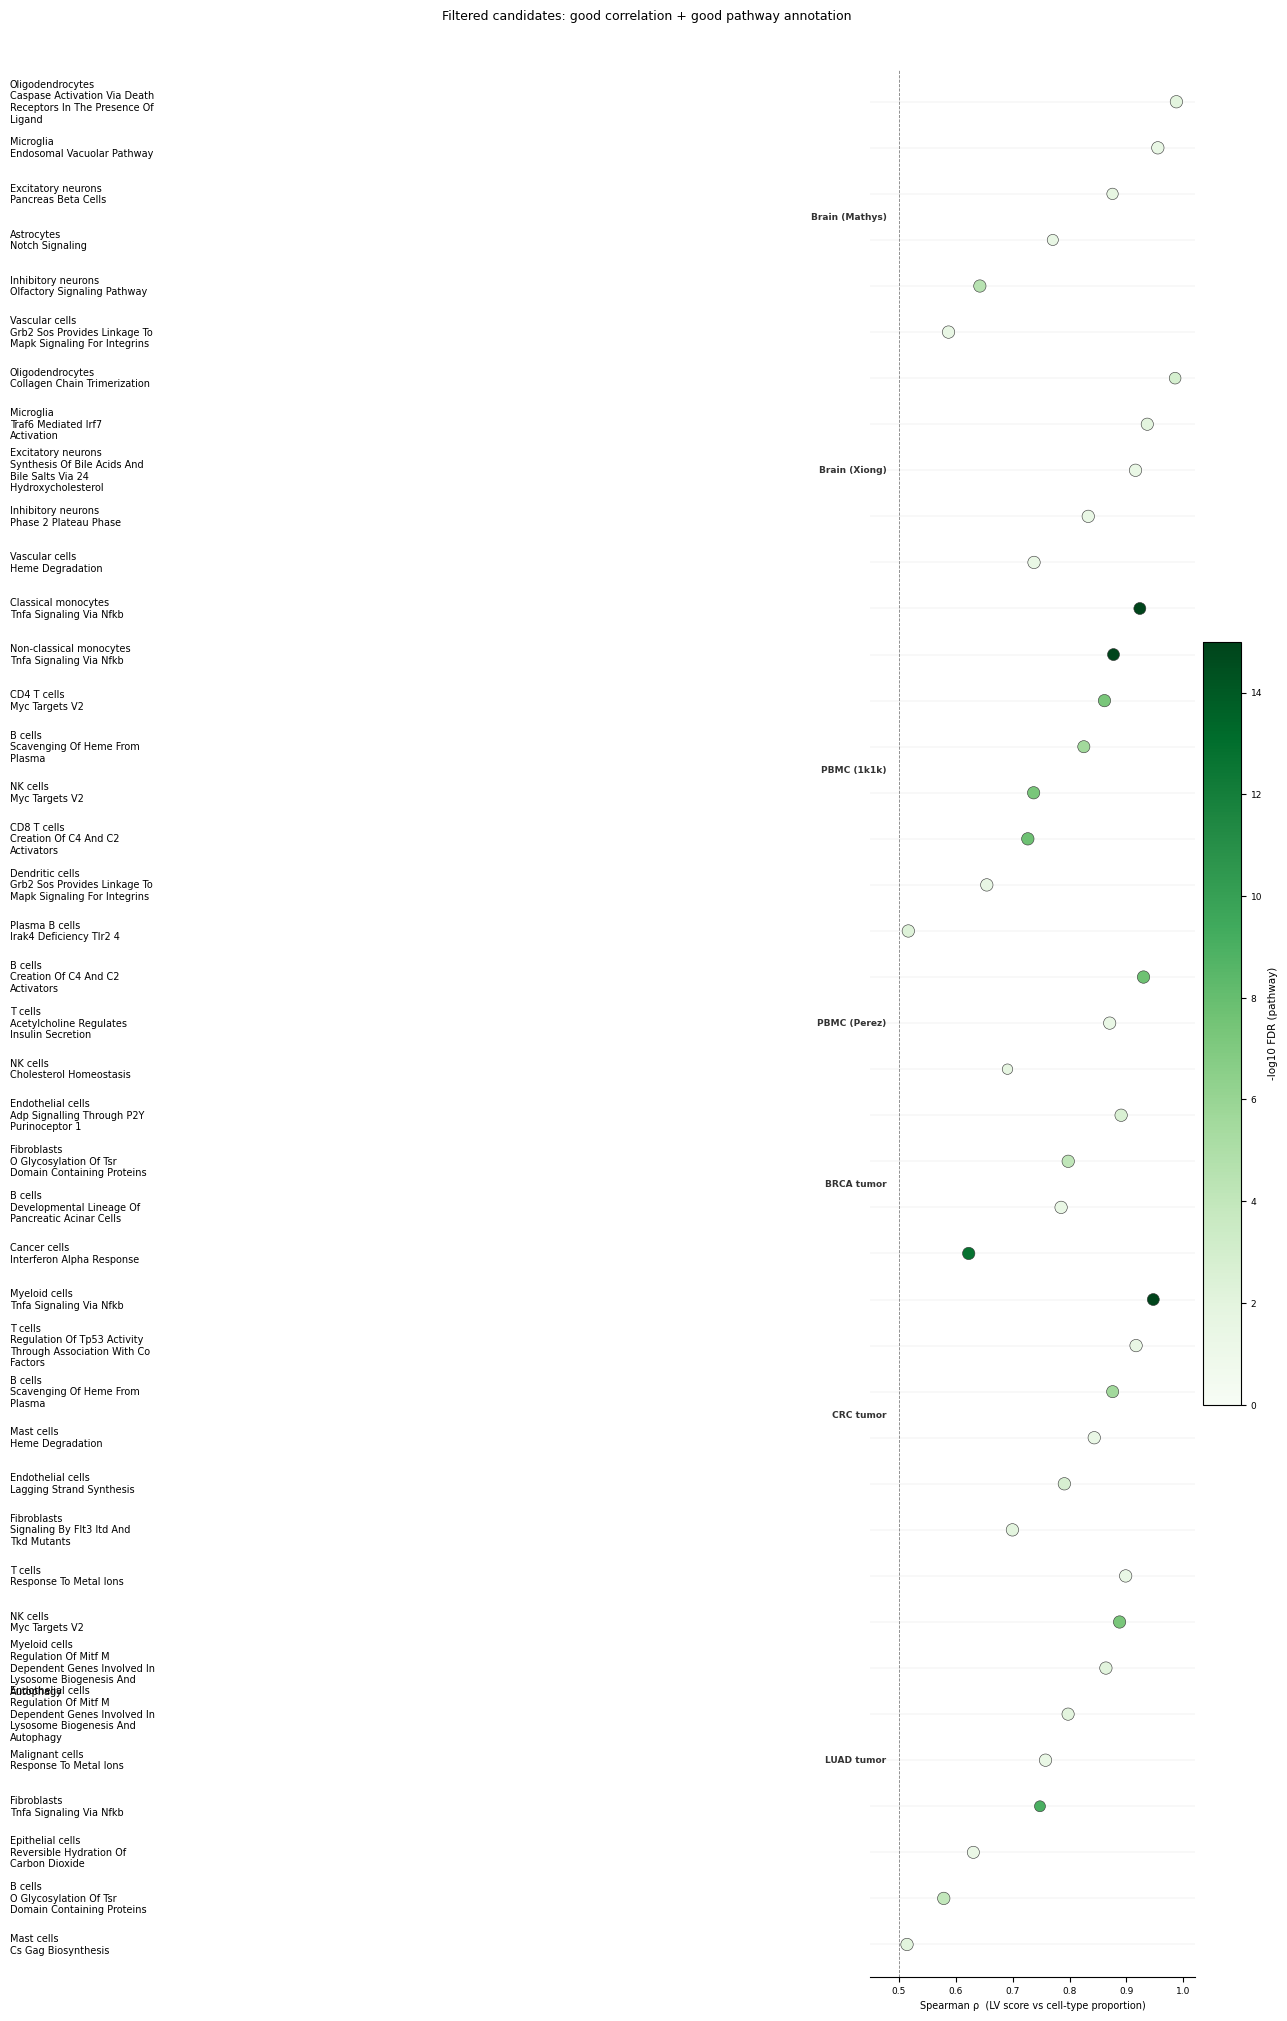

In [7]:
# Forest-plot-style preview: x = rho, y = cell type, color = -log10(FDR), size = AUC
df_filt_plot = df_filt.reset_index(drop=True)
df_filt_plot['y_pos'] = range(len(df_filt_plot), 0, -1)

# Group separators
grp = df_filt_plot.groupby('disp_dataset')['y_pos'].agg(['min','max','mean'])

fig, (ax_label, ax_dot) = plt.subplots(1, 2, figsize=(13, len(df_filt_plot) * 0.45 + 1.5),
                                        gridspec_kw={'width_ratios': [2, 1]})

# Labels
for _, row in df_filt_plot.iterrows():
    ax_label.text(0, row['y_pos'], row['y_label'],
                  ha='left', va='center', fontsize=7, linespacing=1.2)
ax_label.set_xlim(0, 1)
ax_label.set_ylim(0.3, len(df_filt_plot) + 0.7)
ax_label.axis('off')

# Dots
sc = ax_dot.scatter(
    df_filt_plot['rho'], df_filt_plot['y_pos'],
    s=df_filt_plot['pw_auc'] * 80,
    c=df_filt_plot['neg_log_fdr'],
    cmap='Greens', vmin=0, vmax=15,
    edgecolors='#333', linewidths=0.4, zorder=3
)
ax_dot.axvline(0.5, color='grey', linewidth=0.6, linestyle='--')
for _, row in df_filt_plot.iterrows():
    ax_dot.axhline(row['y_pos'], color='grey', linewidth=0.15, alpha=0.5)

# Dataset group labels
for ds_name, gdata in grp.iterrows():
    ax_dot.annotate(ds_name, xy=(ax_dot.get_xlim()[0], gdata['mean']),
                    xytext=(-5, 0), textcoords='offset points',
                    ha='right', va='center', fontsize=6.5,
                    fontweight='bold', rotation=0, color='#333')

ax_dot.set_xlim(0.45, 1.02)
ax_dot.set_ylim(0.3, len(df_filt_plot) + 0.7)
ax_dot.set_xlabel('Spearman ρ  (LV score vs cell-type proportion)', fontsize=7)
ax_dot.set_yticks([])
ax_dot.spines[['top','right','left']].set_visible(False)
plt.colorbar(sc, ax=ax_dot, label='-log10 FDR (pathway)', shrink=0.4, pad=0.02)

plt.suptitle('Filtered candidates: good correlation + good pathway annotation',
             fontsize=9, y=1.01)
plt.tight_layout()
plt.show()